# Week 3 Lab: MNIST Image Classification using Logistic Regression

[PRML 2026 Dr Min Wang]

## Objective
By the end of this tutorial, you will:
- Understand how to load and explore the MNIST dataset.
- Preprocess images for logistic regression.
- Train and evaluate a logistic regression classifier.
- Interpret the results and identify strengths/weaknesses.

## Introduction to MNIST Digit Classification

The MNIST dataset is a widely used benchmark in machine learning and computer vision. It consists of 70,000 grayscale images of handwritten digits (0 through 9), each sized 28×28 pixels. The goal of MNIST digit classification is to develop models that can accurately recognize and classify these images into their correct digit categories.

Because of its simplicity and well-structured format, MNIST serves as an excellent starting point for learning image classification techniques, including logistic regression, neural networks, and deep learning models. Success on MNIST demonstrates a model’s ability to extract meaningful features from image data and make accurate predictions on unseen samples.

In this lab, we will use the logistic regression model for classification. Logistic regression is a simple yet powerful statistical method that predicts the probability of an input belonging to a particular class. For MNIST, it models the probability that an image corresponds to each digit from 0 to 9. Despite its simplicity compared to deep learning models, logistic regression can achieve surprisingly good accuracy on MNIST and serves as a great introduction to classification algorithms.


## Prerequisites
You’ll need:
Python 3.x installed
scikit-learn, numpy, matplotlib, and tensorflow installed

## Step-by-Step Instructions

### Step 1: Import libraries
We import essential libraries for this task:
1. NumPy for numerical operations.
2. Matplotlib for data visualization.
3. scikit-learn for building and evaluating the logistic regression model. LogisticRegression from scikit-learn will be our classifier.
4. classification_report & confusion_matrix help evaluate performance.
5. TensorFlow to load the MNIST dataset easily. We use MNIST directly from Keras for convenience.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.datasets import mnist


### Step 2: Load the MNIST dataset
In this step, we load the MNIST handwritten digit dataset using TensorFlow’s built-in tf.keras.datasets.mnist.load_data() function. This provides the dataset split into training and testing sets directly as NumPy arrays. Each image is a 28x28 grayscale pixel array, and the labels are integers from 0 to 9. This built-in method is convenient and efficient for quick access to the dataset.
1. MNIST contains 28×28 grayscale digit images (0–9).
2. x_train has 60,000 images, x_test has 10,000.

In [16]:
# Load data: (x_train, y_train) for training, (x_test, y_test) for testing
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)


### Step 3: Visualize sample images
Here we display nine images from the training set. This visualization helps familiarize you with the dataset and confirms that the images and labels align.

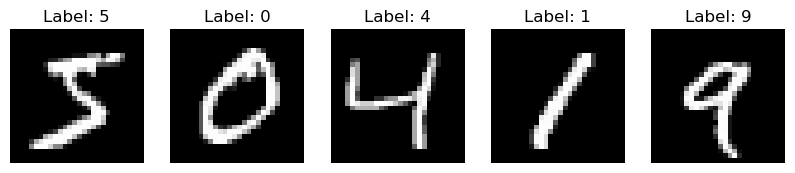

In [17]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


### Step 4: Preprocess the data
Since logistic regression expects input as feature vectors, each 28x28 image will need to be flattened into a one-dimensional 784-length vector. We also normalize pixel values from 0–255 to 0–1 to improve model performance and training stability.
1. Flattening: Logistic regression expects 1D feature vectors.
2. Normalization: Helps model convergence and stability.

In [18]:
# Flatten each 28x28 image into a 784-length vector
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# Normalize pixel values to range [0, 1]
x_train_flat = x_train_flat.astype('float32') / 255.0
x_test_flat = x_test_flat.astype('float32') / 255.0

### Step 5: Build and Train the logistic regression model
We create a multinomial logistic regression model using the 'saga' solver, suitable for multi-class problems and large datasets. Then, the model is trained on the flattened, normalized training images and their labels.
1. Multinomial logistic regression handles multiple classes.
2. saga solver works well for large datasets and supports multinomial loss.
3. During training, the model learns weights for each pixel to distinguish between digits.

In [12]:
# Using 'saga' solver for large datasets and multinomial classification
model = LogisticRegression(
    solver='saga',
    multi_class='multinomial',
    max_iter=100,      # Number of iterations
    verbose=1,         # Show training progress
    n_jobs=-1          # Use all CPU cores for speed
)

# Train the model
model.fit(x_train_flat, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


max_iter reached after 96 seconds


/Users/s448213/.conda/envs/tf/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(multi_class='multinomial', n_jobs=-1, solver='saga',
                   verbose=1)

### Step 6: Evaluate the model
After training, we predict labels for the test dataset. We evaluate the model’s performance using accuracy and detailed classification metrics such as precision, recall, and F1-score.
1. Accuracy gives an overall measure of correct predictions.
2. Confusion matrix shows per-class performance.
3. Classification report gives precision, recall, and F1 score for each digit.

In [19]:
# Accuracy on the test set
accuracy = model.score(x_test_flat, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Predictions for detailed evaluation
y_pred = model.predict(x_test_flat)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.9260
Confusion Matrix:
 [[ 957    0    1    3    1   10    4    3    1    0]
 [   0 1110    5    2    0    2    3    2   11    0]
 [   6   10  929   15   10    3   13   10   32    4]
 [   4    1   16  923    1   24    2   10   20    9]
 [   1    3    7    3  920    0    7    4    7   30]
 [   9    2    3   35   10  777   15    7   30    4]
 [   8    3    8    2    6   15  913    2    1    0]
 [   1    7   23    7    6    1    0  949    2   32]
 [   9   11    6   23    7   29   13    9  855   12]
 [   9    8    1    9   21    7    0   20    7  927]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94 

### Step 7: Visualize the predictions
This step visualizes the first 10 images from the test set where the model predicted the digit correctly. It helps you qualitatively assess the model’s successes. Here we also display the first 10 test images where the model made incorrect predictions, highlighting areas where the model could be improved. Visualisation helps you better understand and interpret your results and model performance.
1. np.where(y_pred == y_test) gets the indices where predictions match the true labels.
2. np.where(y_pred != y_test) gets the indices where they differ.


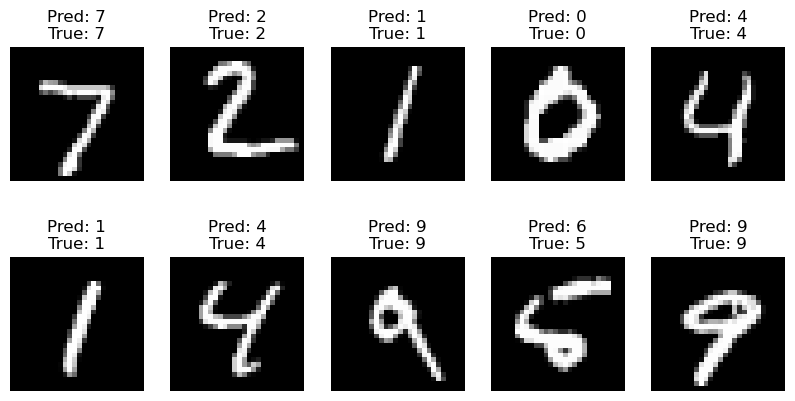

In [20]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Pred: {y_pred[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.show()

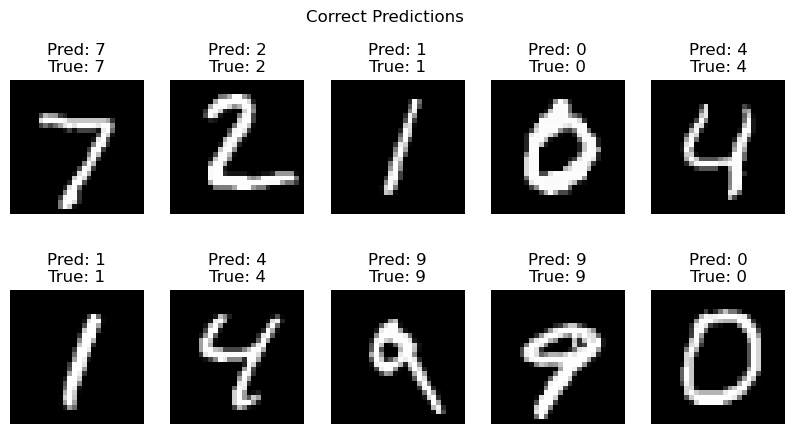

In [21]:
# Find indices of correct and incorrect predictions
correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]

# Visualize first 10 correct predictions
plt.figure(figsize=(10, 5))
for i, idx in enumerate(correct_indices[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Pred: {y_pred[idx]}\nTrue: {y_test[idx]}")
    plt.axis('off')
plt.suptitle("Correct Predictions")
plt.show()

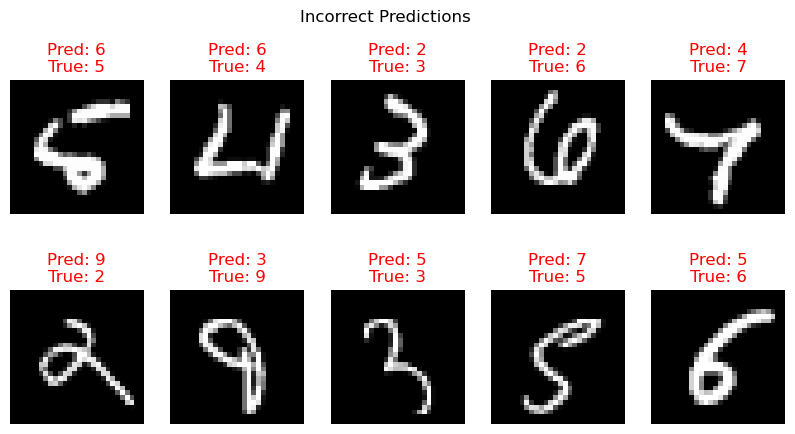

In [22]:
# Visualize first 10 incorrect predictions
plt.figure(figsize=(10, 5))
for i, idx in enumerate(incorrect_indices[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Pred: {y_pred[idx]}\nTrue: {y_test[idx]}", color='red')
    plt.axis('off')
plt.suptitle("Incorrect Predictions")
plt.show()

### Expected Outcome
1. Logistic regression will likely achieve ~92–93% accuracy on MNIST.
2. Errors often occur between similar-looking digits (e.g., 4 vs. 9, 3 vs. 5).

### Summary
While logistic regression is simpler than deep neural networks, it’s still effective for image classification when the dataset is well-structured like MNIST.

